# License

This project is licensed under the GNU Affero General Public License v3.0. See the [LICENSE](LICENSE) file for details.

<h1 style="text-align: center; font-family: 'Arial', sans-serif; color: #2c3e50;">
  <strong>Introduction to Neural Networks Programming and Applied Artificial Intelligence</strong>
</h1>



---



> <p style="text-align: center; font-family: 'Arial', sans-serif; color: #34495e; font-size: 18px;">
  <strong>Course coordinator </strong><br>
  David Gonzalez (gonzal@unizar.es)
</p>

> <p style="text-align: center; font-family: 'Arial', sans-serif; color: #34495e; font-size: 18px;">
  <strong>Authors </strong><br>
  </p>
  Carlos Bermejo-Barbanoj
  </p>
  Alicia Tierz
  </p>
  Mikel M. Iparraguirre
  </p>
  Lucas Tesán
  </p>
  </p>
  Pau Urdeitx


---

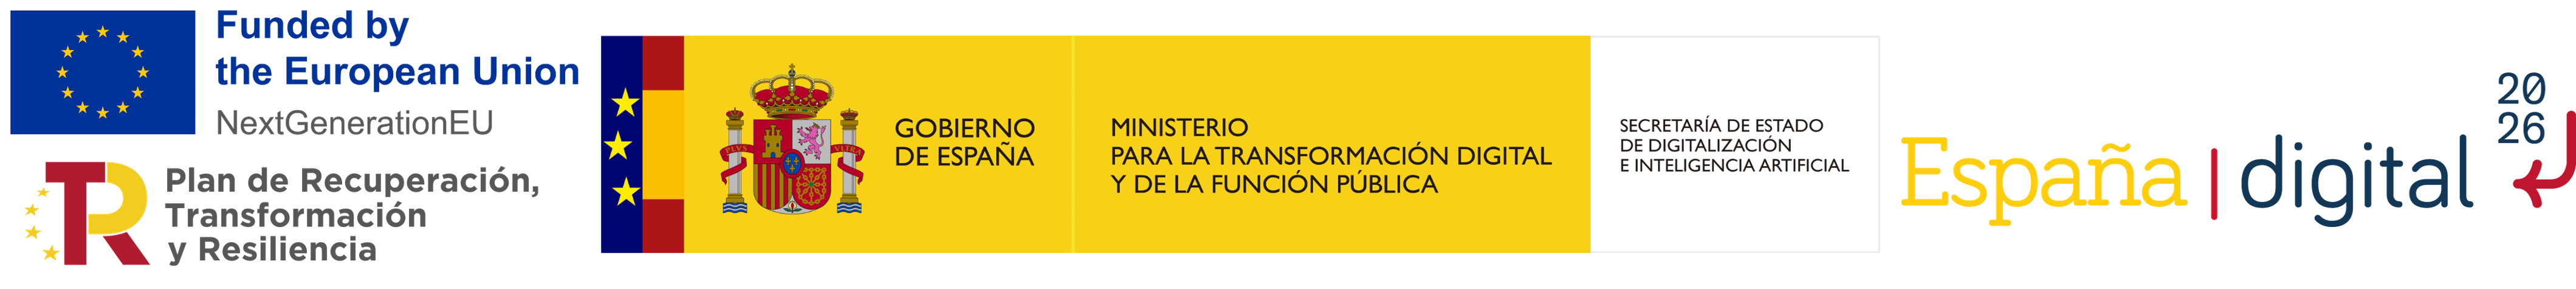

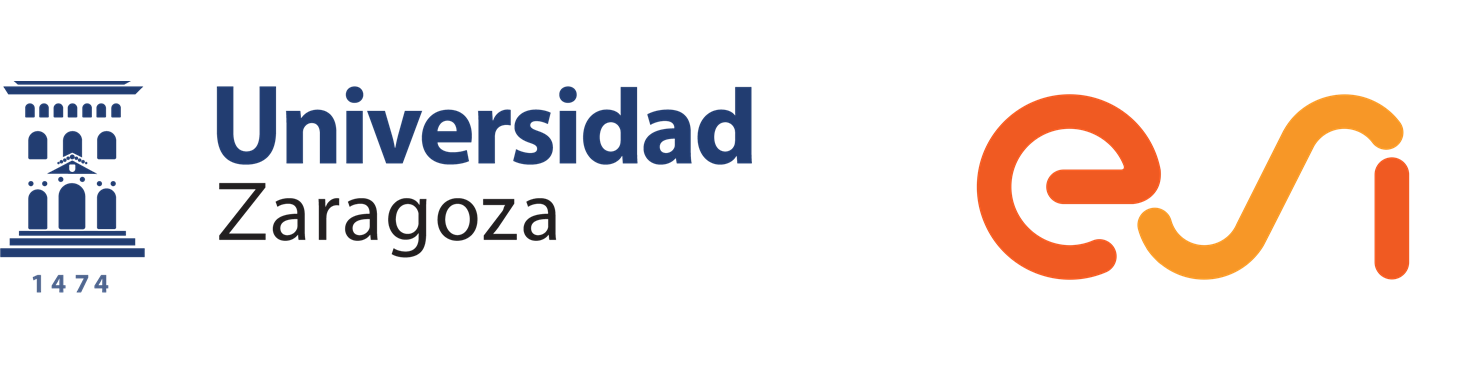

# Chapter 4: From MLPs to CNNs and Autoencoders: Image Classification and Representation Learning with MNIST

---


> <p style="text-align: center; font-family: 'Arial', sans-serif; color: #34495e; font-size: 18px;">
  <strong>Lecture</strong><br>
  Alicia Tierz
</p>

> <p style="text-align: center; font-family: 'Arial', sans-serif; color: #34495e; font-size: 18px;">
  <strong>Notebook Authors</strong><br>
  </p>
  Carlos Bermejo-Barbanoj
  </p>
  Alicia Tierz
  </p>
  Pau Urdeitx
</p>


---

This notebook assumes familiarity with Python and basic programming concepts. Prior knowledge of neural networks is helpful but not required.

## 1. Introduction

In this session, we will build a progressive understanding of how neural networks can be applied to image data. Using the MNIST dataset of handwritten digits, we will begin by designing a simple fully connected classifier (MLP) and later explore how convolutional neural networks (CNNs) improve performance by leveraging spatial information.

We will then introduce **PyTorch Lightning**, a framework that abstracts boilerplate code and facilitates more scalable, readable, and modular deep learning pipelines.

To conclude, we will explore an **Autoencoder** — a type of neural network trained in an unsupervised manner — to introduce the concept of **latent representations** and demonstrate how neural networks can learn to represent and reconstruct input data without explicit labels.

### Objectives

- Train and evaluate a Multi-Layer Perceptron (MLP) for image classification.
- Understand and implement a Convolutional Neural Network (CNN).
- Compare the performance of MLP vs CNN and interpret their strengths and limitations.
- Learn the structure and benefits of using PyTorch Lightning.
- Construct a simple Autoencoder and explore the concept of latent spaces.


##2. Setup
Let's start by first installing the necessary libraries and initialising a random seed to get all the same results.

In [ ]:
'''
Notebook:
    Chapter 4 Getting Started with Neural Networks: Multilayer Perceptron (MLP)
====
Authors of this notebook
  Carlos Bermejo-Barbanoj
  Alicia Tierz
  Pau Urdeitx

- Associated publication:
url: https://eniachair.unizar.es/
====
'''
# Install PyTorch Lightning if not already available
!pip install -q pytorch-lightning

# scipy to import the dataset (generated in matlab)
!pip install scipy

# Imports
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import random
import scipy.io as sio

# load additional packages
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from tqdm import tqdm
from tqdm.notebook import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    pl.seed_everything(seed, workers=True)

set_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 53.7 MB/s eta 0:00:00


INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device: cpu


## 3. Exploring the MNIST Dataset
### What is MNIST?

The **MNIST dataset** (Modified National Institute of Standards and Technology) is a benchmark dataset in the field of machine learning. It consists of **70,000 grayscale images** of handwritten digits (0–9), each of size **28x28 pixels**.

- **Training set**: 60,000 images
- **Test set**: 10,000 images

The goal is to develop models that can accurately classify these images into one of ten digit classes.




100%|██████████| 9.91M/9.91M [00:00<00:00, 152MB/s]


100%|██████████| 28.9k/28.9k [00:00<00:00, 23.4MB/s]


100%|██████████| 1.65M/1.65M [00:00<00:00, 83.1MB/s]


100%|██████████| 4.54k/4.54k [00:00<00:00, 5.11MB/s]


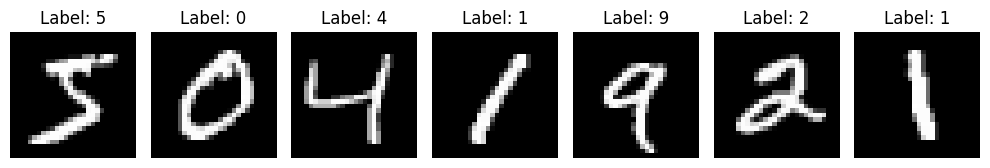

shape of the image: torch.Size([1, 28, 28])


In [16]:
# Define a transform: convert images to tensors and normalize to [0, 1]
transform = transforms.ToTensor()

# Download and load the training dataset
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Visualize the first few samples
def plot_samples(dataset, num_samples=7):
    plt.figure(figsize=(10, 2))
    for i in range(num_samples):
        image, label = dataset[i]
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image.squeeze(), cmap="gray")
        plt.title(f"Label: {label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    print(f'shape of the image: {image.shape}')

plot_samples(mnist_train)


### Data Normalization and DataLoaders

Before feeding data into a neural network, it is standard practice to normalize the input values. In the case of MNIST, the pixel values range from 0 to 255. By applying `transforms.ToTensor()`, the values are automatically scaled to the [0, 1] range.

To further improve training stability, we can normalize the dataset using the mean and standard deviation of the MNIST dataset. These values are:

- **Mean**: 0.1307
- **Standard deviation**: 0.3081

We also create `DataLoader` objects to efficiently handle batches of data during training and evaluation.


In [17]:
len(list(range(len(mnist_train))))


60000

In [18]:
# Normalize with mean and std used for MNIST
transform_norm = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Normalize((0.1307,), (0.3081,))
])

# Reload datasets with normalization
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform_norm)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform_norm)

num_train_samples = 3000
# Creates a list of randomly selected indices
indices = list(range(len(mnist_train)))
random.shuffle(indices)
selected_indices = indices[:num_train_samples]
mnist_train_subset = Subset(mnist_train, selected_indices)


# Create DataLoaders
batch_size = 64
train_loader = DataLoader(mnist_train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")


Training batches: 47
Test batches: 157


## 4. MLP Classifier (with plain PyTorch)

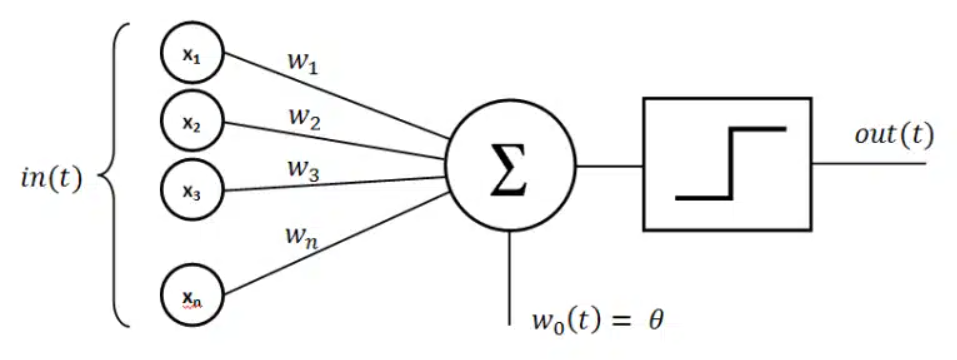

### Define a Simple MLP

We begin by implementing a basic **Multilayer Perceptron (MLP)** for image classification. This network will:

- Flatten the 28x28 pixel input image into a 784-dimensional vector
- Pass it through two fully connected layers with ReLU activations
- Output a 10-dimensional vector, representing the class scores for digits 0–9


In [ ]:
class MLP(nn.Module):
    def __init__(self, dim_output):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),                 # 28x28 → 784
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, dim_output)          # Output: 62 classes
        )

    def forward(self, x):
        return self.model(x)

mlp = MLP(dim_output=10).to(device)
print(mlp)


MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


### Manual Training Loop (Basic PyTorch)

We will now train the MLP using a standard PyTorch training loop. This involves:

1. Iterating over batches from the training DataLoader
2. Performing forward and backward passes
3. Updating weights using the optimizer


In [ ]:
from tqdm.notebook import tqdm
# Define optimizer and loss function
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop
def train(model, loader, optimizer, criterion, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

train(mlp, train_loader, optimizer, criterion, epochs=5)


Epoch 1/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1/5, Loss: 1.1928


Epoch 2/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 2/5, Loss: 0.4416


Epoch 3/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 3/5, Loss: 0.3345


Epoch 4/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 4/5, Loss: 0.2731


Epoch 5/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 5/5, Loss: 0.2383


### Evaluate Accuracy and Performance

Let's evaluate the model's classification accuracy on the test set to understand how well the MLP performs on unseen data.


In [ ]:
def evaluate_and_visualize(model, loader, device, num_images=8):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_images = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # Collect a few samples for visualization
            if len(all_images) < num_images:
                all_images.append(images[:num_images])
                all_preds.append(predicted[:num_images])
                all_labels.append(labels[:num_images])

    accuracy = correct / total * 100
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Combine collected tensors into one batch
    all_images = torch.cat(all_images)[:num_images]
    all_preds = torch.cat(all_preds)[:num_images]
    all_labels = torch.cat(all_labels)[:num_images]

    # Plotting the results
    plt.figure(figsize=(15, 2.5))
    for i in range(num_images):
        img = all_images[i].cpu().squeeze()  # MNIST images are grayscale (1 channel)
        pred = all_preds[i].item()
        true = all_labels[i].item()

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Pred: {pred}\nTrue: {true}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Test Accuracy: 90.89%


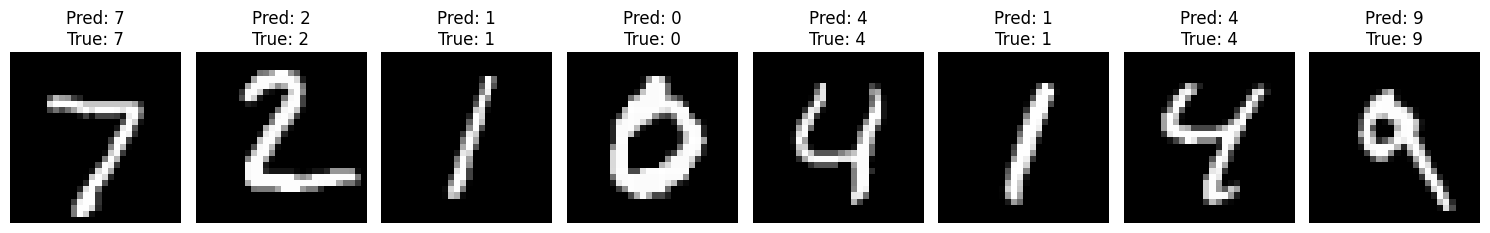

In [ ]:
evaluate_and_visualize(mlp, test_loader, device)

## 5. Convolutional Neural Network (CNN)
A Convolutional Neural Network (CNN) is primarily composed of four types of layers that collaborate to learn and classify patterns :

*   **Convolutional Layers**: These are the fundamental building blocks. Their function is to apply a set of filters (kernels) to an input feature map, such as an image, to generate new feature maps. These filters are designed to capture specific features, ranging from simple elements like edges and colors in the initial layers to larger and more complex shapes as data progresses through the network.
*   **Activation Functions**: These are vital for introducing the necessary non-linearity into the model. Without them, a deep network would be limited to performing a series of linear transformations, drastically restricting its ability to learn complex relationships inherent in real-world data. The Rectified Linear Unit (ReLU) is the most commonly used activation function after each convolution operation, effective in mitigating the vanishing gradient problem.
*   **Pooling Layers**: Their main objective is to extract the most significant features from the feature maps and reduce their spatial dimensions. This reduction is crucial for decreasing memory usage during training and the model's computational complexity, while also helping to mitigate overfitting. The most common types are Max-pooling and Average-pooling.
*   **Fully Connected (FC) Layers:** Located in the final stages of the CNN, these layers receive the flattened output from the convolutional and pooling layers. Their function is to perform the final classification based on the abstract features extracted, often employing a Softmax activation function to generate probability values for each output class.


The integration of these layers allows CNNs to learn features hierarchically. The initial layers of the network focus on detecting primitive features like lines and curves. As more convolutional layers are added, the feature maps become capable of recognizing more complex shapes. This progressive abstraction process is facilitated by pooling layers, which reduce data dimensionality  and, consequently, the number of parameters and necessary calculations.

In [ ]:
class CNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 8, kernel_size=5, padding=2)   # 28x28 → 28x28
        self.pool = nn.MaxPool2d(2, 2)                                     # 28x28 → 14x14
        self.conv2 = nn.Conv2d(8, 16, kernel_size=5, padding=2)           # 14x14 → 14x14
        self.fc1 = nn.Linear(16 * 7 * 7, 64)                               # after pooling: 7x7
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        """
        Build a simple convolutional neural network for image classification.

        Parameters:
        - in_channels (int): Number of input channels (e.g., 1 for grayscale MNIST)
        - num_classes (int): Number of output classes (e.g., 10 for digits 0-9)
        """
        super(CNN, self).__init__()

        # TODO: Create the first convolutional layer
        self.conv1 = nn.Conv2d(in_channels=___, out_channels=___, kernel_size=___, padding=___)

        # TODO: Add a max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=___, stride=___)

        # TODO: Create the second convolutional layer
        self.conv2 = nn.Conv2d(in_channels=___, out_channels=___, kernel_size=___, padding=___)

        # TODO: Define the fully connected layer
        self.fc1 = nn.Linear(___, ___)

        self.fc2 = nn.Linear(___, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))  # Apply conv1
        x = self.pool(x)           # Apply pooling
        x = F.relu(self.conv2(x))  # Apply conv2
        x = self.pool(x)           # Apply pooling

        # TODO: Flatten the tensor before the fully connected layer
        # Hint: Use x.view(batch_size, -1) to collapse dimensions
        x = x.view(___, ___)

        x = self.fc1(x) # Apply the fully connected layer

        return x

In [ ]:
# Define key hyperparameters for the model and training process
in_channels = 1 # MNIST images are grayscale, so 1 input channel
num_classes = 10 # Digits from 0 to 9
learning_rate = 0.001
batch_size = 64
num_epochs = 10


# Instantiate the model and move it to the configured device (GPU/CPU) [8]
model_cnn = CNN(in_channels=in_channels, num_classes=num_classes).to(device)
print(model_cnn)

CNN(
  (conv1): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [ ]:
# Define optimizer and loss function
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
train(model_cnn, train_loader, optimizer, criterion, epochs=5)

Epoch 1/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1/5, Loss: 0.2111


Epoch 2/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 2/5, Loss: 0.1696


Epoch 3/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 3/5, Loss: 0.1460


Epoch 4/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 4/5, Loss: 0.1214


Epoch 5/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 5/5, Loss: 0.1064


In [ ]:
def visualize_intermediate_layers(model, dataset, device, num_filters=8):
    """
    Visualizes intermediate activations after each convolutional layer.

    Parameters:
    - model: The CNN model
    - dataset: A dataset (e.g., MNIST training set)
    - device: torch.device("cpu") or torch.device("cuda")
    - num_filters: Number of filters to visualize per layer
    """
    model.eval()

    # Get a single sample (image and label)
    image, label = dataset[0]
    image = image.unsqueeze(0).to(device)  # Add batch dimension

    print(f"Ground Truth Label: {label}")

    # Forward through each layer manually to grab intermediate results
    with torch.no_grad():
        x = image

        # First convolutional layer
        x1 = model.conv1(x)
        x1_relu = torch.relu(x1)
        x1_pool = model.pool(x1_relu)

        # Second convolutional layer
        x2 = model.conv2(x1_pool)
        x2_relu = torch.relu(x2)
        x2_pool = model.pool(x2_relu)

    def plot_feature_maps(tensor, title):
        num_channels = tensor.shape[1]
        num_to_plot = min(num_filters, num_channels)

        plt.figure(figsize=(15, 3))
        for i in range(num_to_plot):
            plt.subplot(1, num_to_plot, i + 1)
            plt.imshow(tensor[0, i].cpu(), cmap="gray")
            plt.axis("off")
            plt.title(f"Filter {i}")
        plt.suptitle(title)
        plt.show()

    # Plot original input
    plt.imshow(image[0, 0].cpu(), cmap='gray')
    plt.title("Original Input")
    plt.axis("off")
    plt.show()

    # Plot intermediate activations
    plot_feature_maps(x1_relu, "After Conv1 + ReLU")
    plot_feature_maps(x1_pool, "After Conv1 + ReLU + MaxPool")
    plot_feature_maps(x2_relu, "After Conv2 + ReLU")
    plot_feature_maps(x2_pool, "After Conv2 + ReLU + MaxPool")


Ground Truth Label: 5


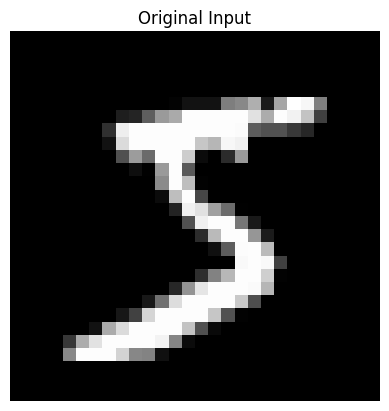

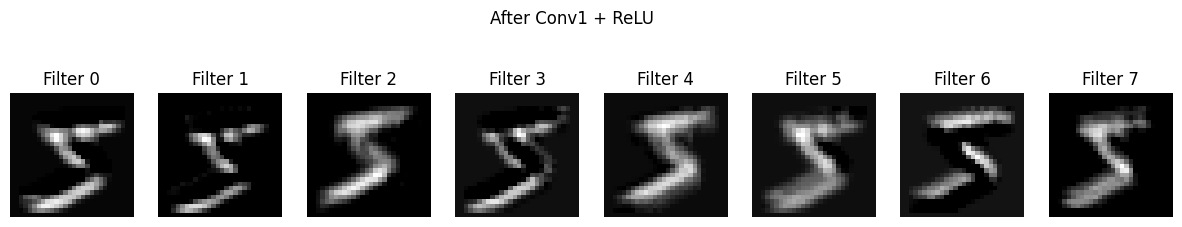

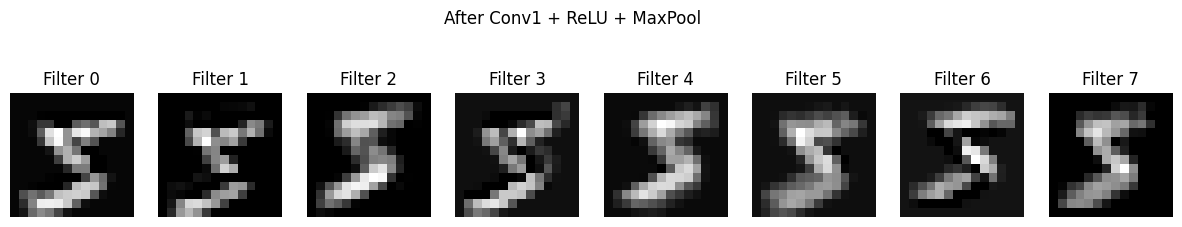

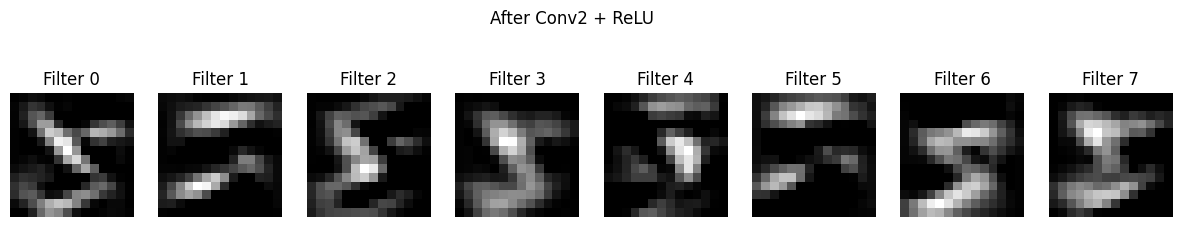

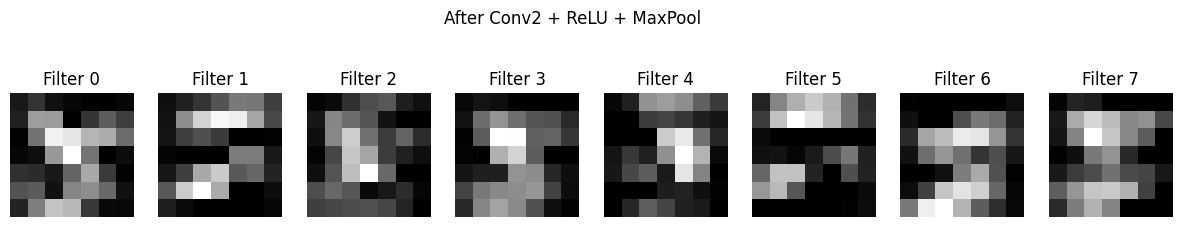

In [ ]:
# Visualize activations
visualize_intermediate_layers(model_cnn, mnist_train, device)


### Evaluate Accuracy and Performance

Let's evaluate the model's classification accuracy on the test set to understand how well the CNN performs on unseen data.


Test Accuracy: 93.23%


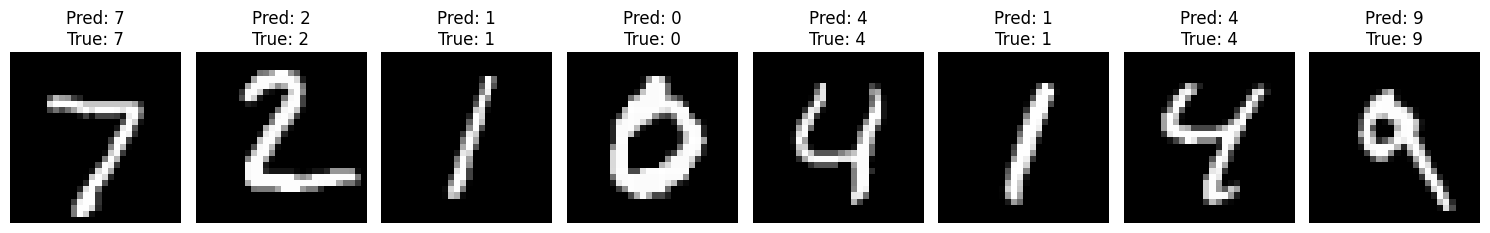

In [ ]:
evaluate_and_visualize(model_cnn, test_loader, device)

## 6. EMNIST Dataset
While the original MNIST dataset (digits 0–9) is useful for learning, it's a relatively easy task. Even simple models like MLPs can achieve over 97% accuracy.
However, in real-world computer vision problems:

* Images are more complex.

* Features like edges, textures, and local patterns matter.

* Spatial information is critical.

To better understand the strengths of Convolutional Neural Networks (CNNs), we will use a more challenging dataset: EMNIST.

**What is EMNIST?**

EMNIST (Extended MNIST) is a dataset of handwritten characters that extends MNIST by including not just digits, but also uppercase and lowercase letters, for a total of 47–62 classes depending on the split used.

Each image is: 28×28 pixels, Grayscale (1 channel) and Labeled with a character class (letters and digits)

Compared to MNIST, EMNIST contains more variability and ambiguity, making it more difficult for simple fully connected networks (MLPs) to generalize well.




**Our Goal**

We'll now train and compare:

* A Multilayer Perceptron (MLP) — treats the image as a flat vector

* A Convolutional Neural Network (CNN) — leverages spatial structure

This comparison will highlight how CNNs are better suited for capturing patterns and shapes in image data, and why they tend to outperform MLPs in more realistic visual recognition tasks.

In [ ]:
from torchvision.datasets import CIFAR10, EMNIST

transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Normalize((0.5,), (0.5,))
])

emnist_train = EMNIST(root='./data', split='byclass', train=True, download=True, transform=transform_cifar)
emnist_test = EMNIST(root='./data',  split='byclass',train=False, download=True, transform=transform_cifar)

100%|██████████| 562M/562M [00:11<00:00, 48.7MB/s]


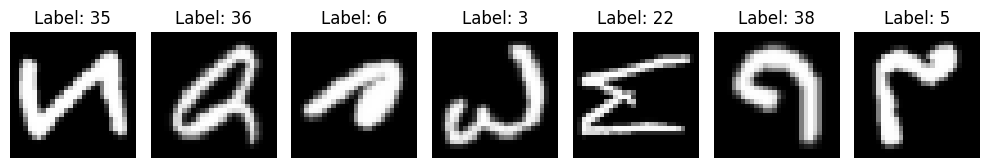

shape of the image: torch.Size([1, 28, 28])
Training batches: 313
Test batches: 313


In [ ]:
plot_samples(emnist_train)

num_train_samples = 20000
# Creates a list of randomly selected indices
indices = list(range(len(emnist_train)))
random.shuffle(indices)
selected_indices = indices[:num_train_samples]
emnist_train_subset = Subset(emnist_train, selected_indices)
emnist_test_subset = Subset(emnist_test, range(num_train_samples))



# Create DataLoaders
batch_size = 64
emnist_train_loader = DataLoader(emnist_train_subset, batch_size=batch_size, shuffle=True,)
emnist_test_loader = DataLoader(emnist_test_subset, batch_size=batch_size, shuffle=False)


print(f"Training batches: {len(emnist_train_loader)}")
print(f"Test batches: {len(emnist_test_loader)}")

### Introducing PyTorch Lightning

As our models grow more complex, managing training loops, validation, logging, and optimization manually can become repetitive and error-prone. PyTorch Lightning is a lightweight wrapper for PyTorch that organizes your code cleanly and removes boilerplate, making your deep learning experiments easier to write, read, and reproduce.


**Why Use PyTorch Lightning?**


* Clean Code -> Keeps your model logic separate from the training logic.

* Less Boilerplate -> Handles device placement, optimization steps, and training loops for you.

* Easy Scaling -> You can train on CPUs, GPUs, TPUs, or even multiple GPUs with just one line of code.

* Logging Made Simple -> Automatically tracks loss, accuracy, and more — with support for tools like TensorBoard.

* Reproducibility -> Makes your experiments easier to track, save, and share.


**How It Works**

PyTorch Lightning introduces a special class called LightningModule where:

* You define your model, loss function, optimizer, and training logic.

* You don’t need to write optimizer.zero_grad(), loss.backward(), or optimizer.step().

* A Trainer class handles the training and validation loops for you.

You’ll continue to use your familiar CNN or MLP, but wrap them in a LightningModule to get all these benefits.

📝 In short: PyTorch Lightning keeps your deep learning code short, scalable, and elegant.

In [ ]:

class LitClassifier(pl.LightningModule):
    def __init__(self, model, lr=0.0001):
        super().__init__()
        self.model = model
        self.criterion = nn.CrossEntropyLoss()
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        acc = (outputs.argmax(dim=1) == labels).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


In [ ]:
from pytorch_lightning import Trainer

num_classes = 62
mlp = MLP(dim_output=num_classes).to(device)

# Wrap the model with LightningModule
lit_model = LitClassifier(mlp, lr=0.001)  # or MLP()

# Define the trainer
trainer = Trainer(max_epochs=8, accelerator="auto", devices=1)

# Fit the model
trainer.fit(lit_model, train_dataloaders=emnist_train_loader)


INFO:pytorch_lightning.utilities.rank_zero:Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | model     | MLP              | 216 K  | train
1 | criterion | CrossEntropyLoss | 0      | train
-------------------------------------------------------
216 K     Trainable params
0         Non-trainable params
216 K     Total params
0.868     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=8` reached.


Test Accuracy: 76.73%


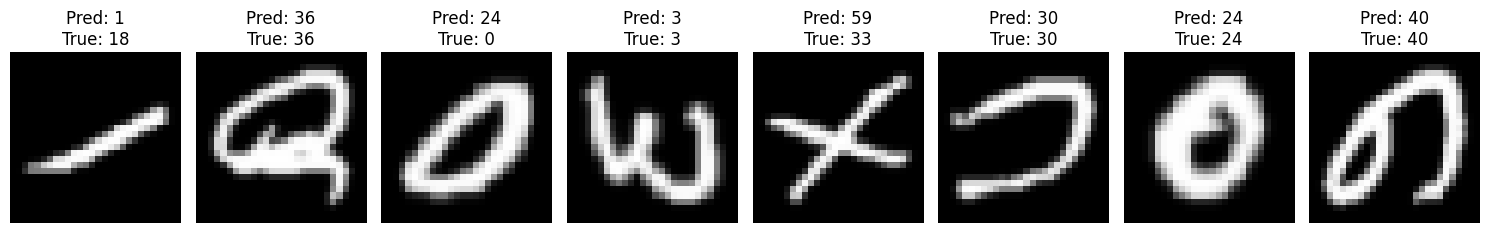

In [ ]:
evaluate_and_visualize(lit_model, emnist_test_loader, device)

In [ ]:
# Wrap the model with LightningModule

CNN(in_channels=in_channels, num_classes=num_classes).to(device)
lit_model_cnn = LitClassifier(CNN(in_channels=in_channels, num_classes=num_classes).to(device), lr=0.001)

# Define the trainer
trainer_cnn = Trainer(max_epochs=8, accelerator="auto", devices=1)

# Fit the model
trainer_cnn.fit(lit_model_cnn, train_dataloaders=emnist_train_loader)


INFO:pytorch_lightning.utilities.rank_zero:Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | model     | CNN              | 57.7 K | train
1 | criterion | CrossEntropyLoss | 0      | train
-------------------------------------------------------
57.7 K    Trainable params
0         Non-trainable params
57.7 K    Total params
0.231     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=8` reached.


Test Accuracy: 80.84%


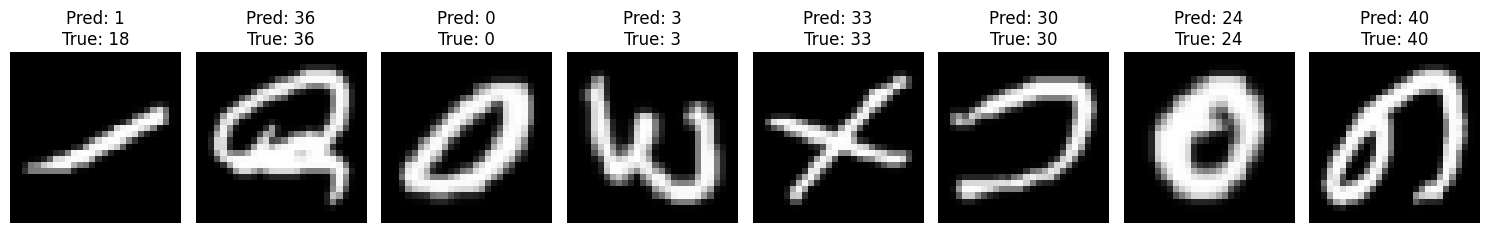

In [ ]:
evaluate_and_visualize(lit_model_cnn, emnist_test_loader, device)

**Conclusion**:

Why CNNs Matter for Image Recognition
In this experiment, we compared two types of neural networks on the FashionMNIST dataset:

* A Multilayer Perceptron (MLP), which treats each image as a flat vector of pixels and with 200k parameters

* A Convolutional Neural Network (CNN), which preserves the spatial structure of the image and uses filters to detect visual patterns and with 58k parameters

With almost 4 times fewer parameters, the convolutional network achieves better results on the inference of test data than the mlp.

This structure makes CNNs far more effective for visual tasks, especially when the input is more complex than digits.

## 7. Introduction to Autoencoders
Autoencoders are a special type of neural network used to learn efficient, compressed representations of input data — typically for dimensionality reduction or data denoising.

Unlike classifiers, autoencoders do not require labels. They learn to compress (encode) the input and then reconstruct (decode) it as accurately as possible.

**Autoencoder Architecture Overview**
An autoencoder has two main parts:

* Encoder: Maps the input to a lower-dimensional representation (a bottleneck).

* Decoder: Tries to reconstruct the original input from the compressed representation.

The training objective is to minimize the reconstruction error — how different the output is from the input.

Let's now build a simple autoencoder for the MNIST letters dataset. We'll see how it learns to compress and reconstruct handwritten characters.

In [ ]:
import torch
import torch.nn as nn
import pytorch_lightning as pl

class ConvAutoencoder(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.lr = lr

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, output_padding=1, padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, output_padding=1, padding=1),   # 14x14 -> 28x28
            nn.Sigmoid()  # Output in [0, 1]
        )

        self.criterion = nn.MSELoss()

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def training_step(self, batch, batch_idx):
        x, _ = batch
        x_hat = self(x)
        loss = self.criterion(x_hat, x)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, _ = batch
        x_hat = self(x)
        loss = self.criterion(x_hat, x)
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


In [ ]:
conv_autoencoder = ConvAutoencoder()

trainer = pl.Trainer(max_epochs=8, accelerator="auto", devices=1)
trainer.fit(conv_autoencoder, train_dataloaders=train_loader, val_dataloaders=test_loader)


INFO:pytorch_lightning.utilities.rank_zero:Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | encoder   | Sequential | 1.2 K  | train
1 | decoder   | Sequential | 1.2 K  | train
2 | criterion | MSELoss    | 0      | train
-------------------------------------------------
2.5 K     Trainable params
0         Non-trainable params
2.5 K     Total params
0.010     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=8` reached.


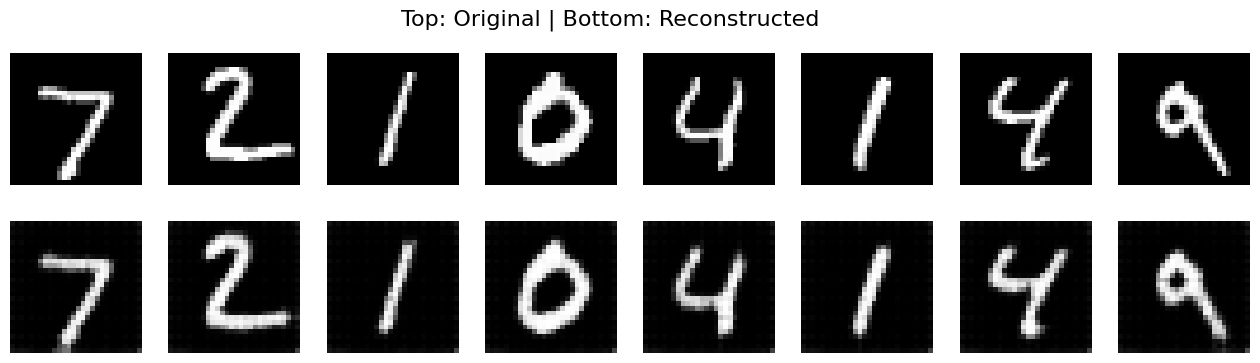

In [ ]:
def show_reconstructions(model, dataloader, num_images=8):
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(dataloader))
        x = x.to(model.device)
        x_hat = model(x)

    x = x.cpu().numpy()
    x_hat = x_hat.cpu().numpy()

    plt.figure(figsize=(16, 4))
    for i in range(num_images):
        # Original
        plt.subplot(2, num_images, i + 1)
        plt.imshow(x[i][0], cmap='gray')
        plt.axis('off')
        # Reconstructed
        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(x_hat[i][0], cmap='gray')
        plt.axis('off')
    plt.suptitle("Top: Original | Bottom: Reconstructed", fontsize=16)
    plt.show()
show_reconstructions(conv_autoencoder, test_loader)

torch.Size([1, 16, 7, 7])


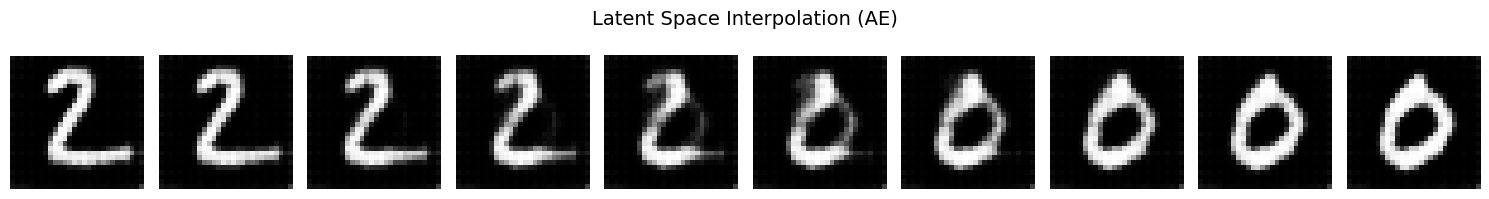

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

def interpolate_latent_space(model, dataloader, steps=10):
    model.eval()
    with torch.no_grad():
        # Get two different images from the dataloader
        for x, _ in dataloader:
            x1, x2 = x[1:2].to(model.device), x[3:4].to(model.device)
            break

        z1 = model.encoder(x1)
        z2 = model.encoder(x2)
        print(z1.shape)
        # Linear interpolation between z1 and z2
        interpolated_imgs = []
        for alpha in torch.linspace(0, 1, steps):
            z = (1 - alpha) * z1 + alpha * z2
            recon = model.decoder(z)
            interpolated_imgs.append(recon.squeeze(0).cpu())
    fig, axs = plt.subplots(1, steps, figsize=(steps * 1.5, 2))
    for i in range(steps):
        axs[i].imshow(interpolated_imgs[i][0], cmap='gray')
        axs[i].axis('off')
    plt.suptitle("Latent Space Interpolation (AE)", fontsize=14)
    plt.tight_layout()
    plt.show()

interpolate_latent_space(conv_autoencoder, test_loader, steps=10)


Autoencoders are a powerful tool for learning compressed, meaningful representations of data. In this section:

* We trained an autoencoder on MNIST.

* We observed how the network learned to reconstruct handwritten numbers.

* You can now experiment by reducing the bottleneck size or changing the encoder/decoder architecture.


**Homeworks**: Try building a denoising autoencoder by adding noise to inputs and training it to recover the clean image!

### VAE

While traditional Autoencoders learn to compress and reconstruct input data through a deterministic bottleneck, they lack the ability to generate new, meaningful samples. **Variational Autoencoders** (VAEs) address this limitation by introducing a probabilistic framework. Instead of encoding inputs into fixed latent vectors, VAEs **learn a distribution** (typically Gaussian) over the latent space. This allows the model to sample from the latent space and generate diverse, coherent outputs.

The key idea behind VAEs is to balance two objectives:

* **Reconstruction loss**: Ensuring the decoded samples resemble the original inputs.

* **KL divergence loss**: Encouraging the latent distributions to stay close to a known prior (usually a standard normal distribution).

This combination enables VAEs to learn smooth and continuous latent spaces, making them powerful tools for **data generation**, interpolation, and representation learning.

In the next section, we'll implement a convolutional VAE and compare its behavior to the standard Autoencoder.

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import pytorch_lightning as pl
import torch
from torch import nn
import torch.nn.functional as F

class VAE(pl.LightningModule):
    def __init__(self, latent_dim=2, lr=1e-3):
        super().__init__()
        self.latent_dim = latent_dim
        self.lr = lr

        # Encoder convolucional
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )
        self.flatten = nn.Flatten()  # <-- flatten needed before Linear

        # Fully connected layers to latent space
        self.fc_mu = nn.Linear(16 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(16 * 7 * 7, latent_dim)

        # Fully connected layer to go from latent space to decoder input
        self.decoder_input = nn.Linear(latent_dim, 16 * 7 * 7)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, padding=1, output_padding=1),   # 14x14 -> 28x28
            nn.Sigmoid()  # Output in [0, 1]
        )

    def encode(self, x):
        h = self.encoder(x)
        h = self.flatten(h)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, 16, 7, 7)  # Reshape to match ConvTranspose2d input
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def training_step(self, batch, batch_idx):
        x, _ = batch
        x_hat, mu, logvar = self(x)
        recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum')
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + 0.5 * kl_div
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)



**Note on the Reconstruction Loss in VAEs**

In Variational Autoencoders, we often use binary cross-entropy (BCE) as the reconstruction loss instead of mean squared error (MSE). This is because VAEs are typically trained on image data normalized to the range [0, 1], and the decoder ends with a Sigmoid activation. BCE treats each pixel as a Bernoulli variable, aligning well with the probabilistic formulation of VAEs. While MSE can still be used, BCE usually provides more meaningful gradients for training, leading to better reconstructions and smoother latent spaces.

In [19]:
vae_model = VAE(latent_dim=20)

trainer = pl.Trainer(max_epochs=15, accelerator="auto", devices=1)
trainer.fit(vae_model, train_dataloaders=train_loader)

INFO:pytorch_lightning.utilities.rank_zero:Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type       | Params | Mode 
-----------------------------------------------------
0 | encoder       | Sequential | 1.2 K  | train
1 | flatten       | Flatten    | 0      | train
2 | fc_mu         | Linear     | 15.7 K | train
3 | fc_logvar     | Linear     | 15.7 K | train
4 | decoder_input | Linear     | 16.5 K | train
5 | decoder       | Sequential | 1.2 K  | train
-----------------------------------------------------
50.3 K    Trainable params
0         Non-trainable params
50.3 K   

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


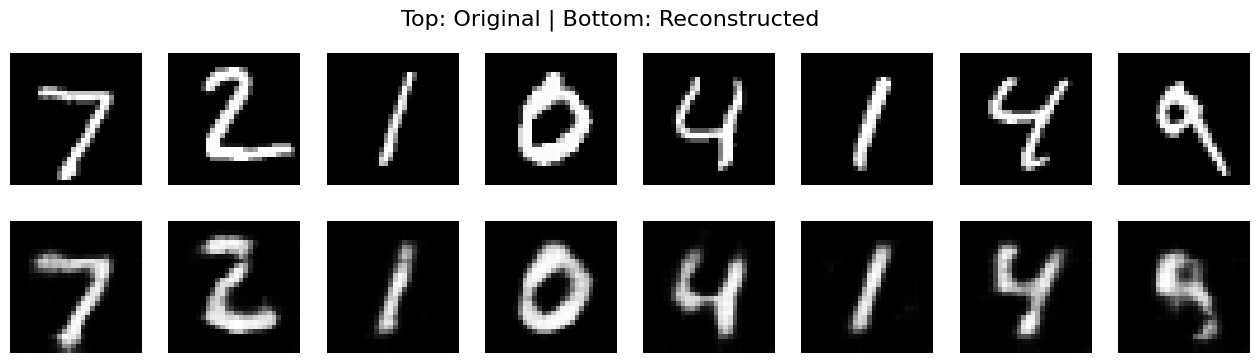

In [20]:
def show_reconstructions_vae(model, dataloader, num_images=8):
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(dataloader))
        x = x.to(model.device)
        x_hat = model(x)[0]

    x = x.cpu().numpy()
    x_hat = x_hat.cpu().numpy()

    plt.figure(figsize=(16, 4))
    for i in range(num_images):
        # Original
        plt.subplot(2, num_images, i + 1)
        plt.imshow(x[i][0], cmap='gray')
        plt.axis('off')
        # Reconstructed
        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(x_hat[i][0], cmap='gray')
        plt.axis('off')
    plt.suptitle("Top: Original | Bottom: Reconstructed", fontsize=16)
    plt.show()
show_reconstructions_vae(vae_model, test_loader)

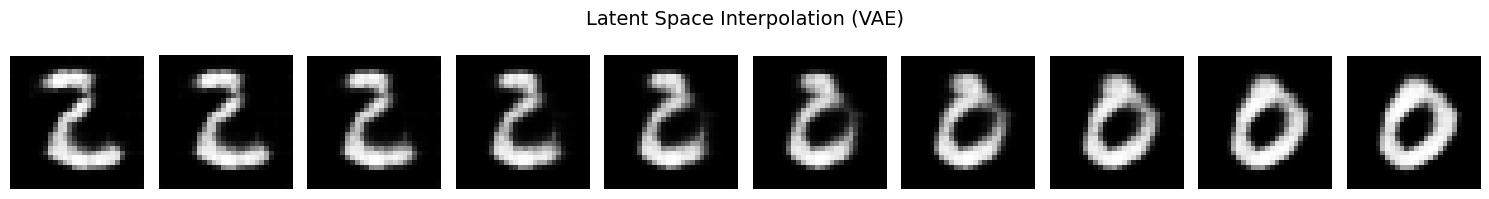

In [21]:
def interpolate_latent_space_vae(model, dataloader, steps=10):
    model.eval()
    with torch.no_grad():
        for x, _ in dataloader:
            x1, x2 = x[1:2].to(model.device), x[3:4].to(model.device)
            break

        # Obtener los vectores mu (sin muestreo)
        z1, _ = model.encode(x1)
        z2, _ = model.encode(x2)

        interpolated_imgs = []
        for alpha in torch.linspace(0, 1, steps):
            z = (1 - alpha) * z1 + alpha * z2
            recon = model.decode(z)
            interpolated_imgs.append(recon.squeeze(0).cpu())

    fig, axs = plt.subplots(1, steps, figsize=(steps * 1.5, 2))
    for i in range(steps):
        axs[i].imshow(interpolated_imgs[i][0], cmap='gray')
        axs[i].axis('off')
    plt.suptitle("Latent Space Interpolation (VAE)", fontsize=14)
    plt.tight_layout()
    plt.show()

interpolate_latent_space_vae(vae_model, test_loader, steps=10)


We compared a simple Convolutional Autoencoder (AE) with a Variational Autoencoder (VAE) using the same dataset and similar convolutional architectures. We observed that the AE produces sharper and more accurate reconstructions, especially after a few epochs of training. This is expected, as the AE directly minimizes reconstruction loss without the constraint of regularizing the latent space.

However, the VAE, despite generating slightly blurrier reconstructions, demonstrates a much smoother and more meaningful latent space, which enables high-quality interpolation between data points. This is a key advantage of VAEs: they learn a structured, continuous latent space that can be sampled and manipulated in a semantically coherent way.

In summary:

* AE excels at reconstruction quality.

* VAE offers better latent space properties for generation and interpolation.

Both models have different strengths and are suited for different tasks depending on whether reconstruction fidelity or generative capabilities are the main goal.

## Final Thoughts

Throughout this notebook, we've explored fundamental building blocks of deep learning using PyTorch and PyTorch Lightning. We began with Multi-Layer Perceptrons (MLPs) and moved on to Convolutional Neural Networks (CNNs) to better handle image data. Along the way, we utilized popular datasets like MNIST and EMNIST to train and evaluate our models. Finally, we introduced Autoencoders (AE) and Variational Autoencoders (VAE) to learn compact representations of images and explore the structure of the latent space. These experiments not only showcased key neural network architectures but also demonstrated the importance of choosing the right model depending on the task—whether it's classification, reconstruction, or generation


# **License**

This notebook is free software: you can redistribute it and/or modify it under the terms of the GNU Affero General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This notebook is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU Affero General Public License for more details.

You should have received a copy of the GNU Affero General Public License along with this notebook. If not, see <https://www.gnu.org/licenses/>.